<a href="https://colab.research.google.com/github/Areeba-Nizami/ML/blob/Task-3/TASK3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#1.	Dataset Acquisition and Preparation:

In [ ]:

csv_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(csv_url)
df.head()


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
print("---Datatypes:")
df.dtypes
print("---MISSING VALUES:")
print(df.isna().sum())

print("---DUPLICATE ROWS:")
print(df.duplicated().sum())

print("---SUMMARY STATICS")
print(df.describe())

---Datatypes:
---MISSING VALUES:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64
---DUPLICATE ROWS:
0
---SUMMARY STATICS
             crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

  

#2.	Data Splitting for Model Validation



In [ ]:
x=df.drop('medv',axis=1)
y=df['medv']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("TRAIN SHAPE:", x_train.shape)
print("TEST SHAPE:", x_test.shape)


TRAIN SHAPE: (404, 13)
TEST SHAPE: (102, 13)


#3.	Linear Regression Model Training and Evaluation:


In [ ]:
model=LinearRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)

mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
mae=mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")


MAE: 3.189
RMSE: 4.929
R²: 0.669


#4	Results Visualization:


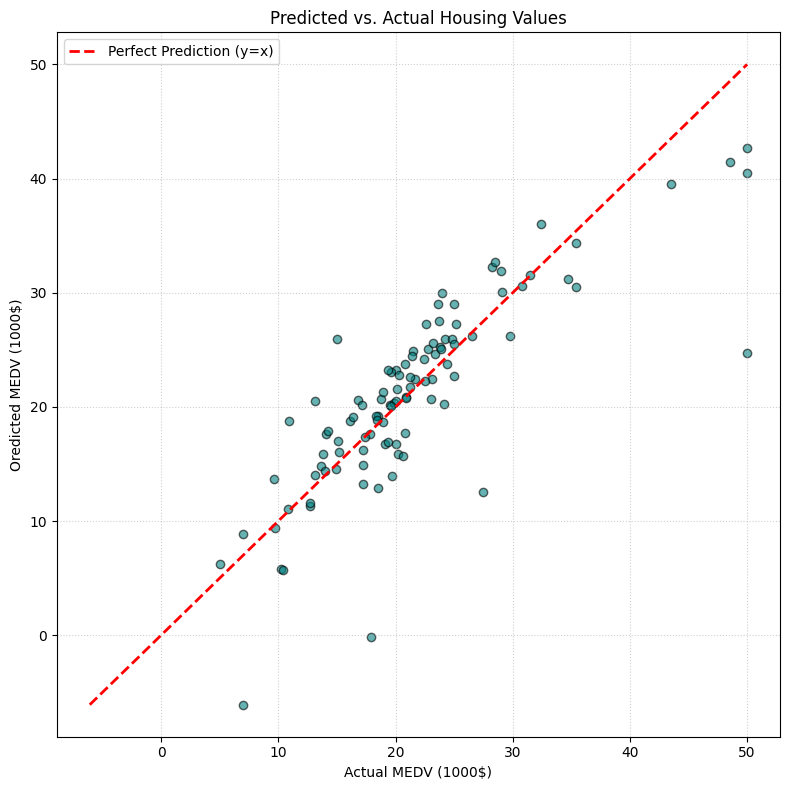

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor='k', color='teal')
limits=[min(y_test.min(),y_pred.min()),max(y_test.max(),y_pred.max())]

plt.plot(limits,limits,'r--',lw=2, label='Perfect Prediction (y=x)')

plt.xlabel('Actual MEDV (1000$)')
plt.ylabel('Oredicted MEDV (1000$)')

plt.title('Predicted vs. Actual Housing Values')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=300)
plt.show()

In [ ]:
negative_preds = y_pred[y_pred < 0]
print("Number of negative predictions:", len(negative_preds))
print(negative_preds)

x_test[y_pred < 0]


Number of negative predictions: 2
[-6.08842184 -0.164237  ]


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
414,45.7461,0.0,18.1,0,0.693,4.519,100.0,1.6582,24,666,20.2,88.27,36.98
412,18.8110,0.0,18.1,0,0.597,4.628,100.0,1.5539,24,666,20.2,28.79,34.37


1. Model Accuracy: The model explains why house prices differ from each other with an accuracy of roughly 67%. The remaining 33% comes down to things the model is missing or cannot capture.

2. Average Error: On average, our model's predictions are off by a gap of about 3,200 (using our MAE of 3.189).

3. (RMSE): Our RMSE (4,930) is quite a bit higher than our MAE (3,200). This difference tells us that while most predictions are decent, the model makes a few really big mistakes on certain houses, which drags this specific score up.

4. Where it works best: Looking at the scatter plot, the predictions match up with the actual values pretty closely when houses cost between $15k and $35k. You can see these teal dots clustering right around the red diagonal line.

5. Data Limits: The dataset has a major built-in limitation. Any house price that exceeded $50k was  labeled exactly as 50k in the data. Because there is a  cap at 50k, the model naturally makes inaccurate predictions for any property beyond that.

6. Negative House Prices: The model spit out two impossible negative predictions (-6,088 and -164), which is obviously wrong since a house can't cost less than zero. Looking at the data, this happened because those two specific rows had an extreme combination of massive crime rates, high local poverty, and very few rooms. These harsh factors pulled the value down drastically.

CONCLUSION:
This task shows exactly what goes wrong when using standard Linear Regression on real-world data. First, it is way too sensitive to extreme outliers as we saw with the high crime rates pulling predictions into negative numbers. Second, it doesn't know how to follow real-world rules; it has no way of knowing it needs to stop at zero or cap things at 50k. While it works fine as a basic tool for average mid-range houses, we would need a more advanced model  to handle extreme data points and price caps properly.